In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

from scipy.stats import pointbiserialr, chi2_contingency
from statsmodels import api as sm
from statsmodels.formula.api import ols

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import LabelEncoder

from matplotlib import pyplot as plt
from func import *

# Load data

In [2]:
data = pd.read_csv('data/heart_2020_cleaned.csv')
data.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

# Numerous features

In [4]:
data.select_dtypes(exclude=['object'])

,BMI,PhysicalHealth,MentalHealth,SleepTime
0,16.60,3.0,30.0,5.0
1,20.34,0.0,0.0,7.0
2,26.58,20.0,30.0,8.0
3,24.21,0.0,0.0,6.0
4,23.71,28.0,0.0,8.0
...,...,...,...,...
319790,27.41,7.0,0.0,6.0
319791,29.84,0.0,0.0,5.0
319792,24.24,0.0,0.0,6.0
319793,32.81,0.0,0.0,12.0


In [5]:
check_data = data.select_dtypes('float').copy()

check_data['HeartDisease'] = data['HeartDisease'].copy()
check_data['HeartDisease_no'] = check_data['HeartDisease'].replace({'No':0, 'Yes':1}).values

## BMI

In [6]:
colname='BMI'

### Distribution

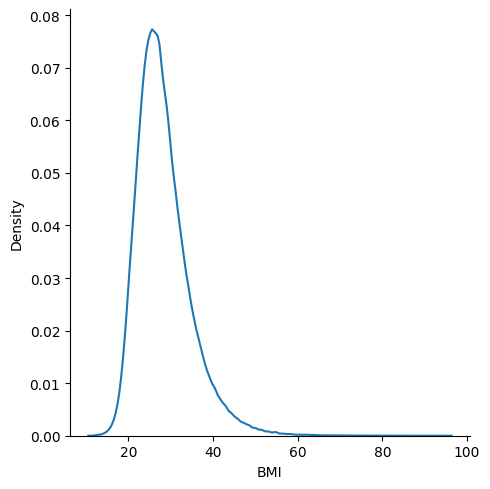

In [7]:
sns.displot(data=data, x=colname, kind='kde');

Nhận xét:
+ Hơi lệch phải.
+ Đuôi hơi dài.

--> Vấn đề về outlier.

### Difference checking between 'BMI' and 'HeartDisease'

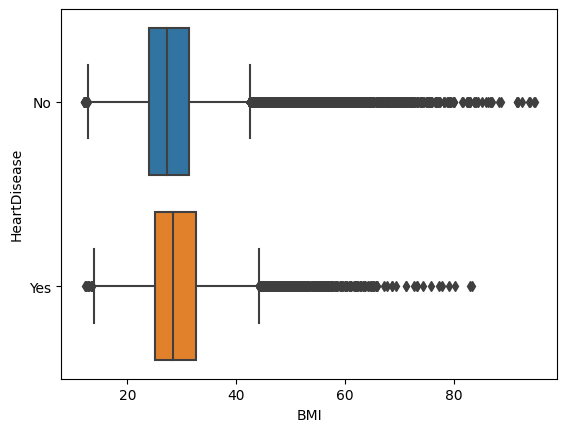

In [8]:
sns.boxplot(data=data, x=colname, y='HeartDisease');

Ta thấy biến BMI có ảnh hưởng nhẹ lên biến HeartDisease. Tính toán hệ số tương quan để kiểm chứng.

### Correlation checking

In [9]:
model = ols(f'HeartDisease_no ~ {colname}', data=check_data).fit()            
coff = pointbiserialr(check_data[colname], check_data['HeartDisease_no'])
    
display(sm.stats.anova_lm(model, typ=2))
print(f'Correlation coefficient: {coff[0]}')
print(f'P-value: {coff[1]}')

,sum_sq,df,F,PR(>F)
BMI,67.169759,1.0,860.496283,6.779455e-189
Residual,24962.825726,319793.0,NaN,NaN


Correlation coefficient: 0.05180319065578071
P-value: 6.779455031636189e-189


Nhận xét:
+ P-value < 0.05 ==> chấp nhận giả thuyết rằng giữa 2 biến có sự tương quan yếu mang ý nghĩa thống kê.
+ Song do có quá nhiều outlier nên ko thể chắc chắn.

### No outlier

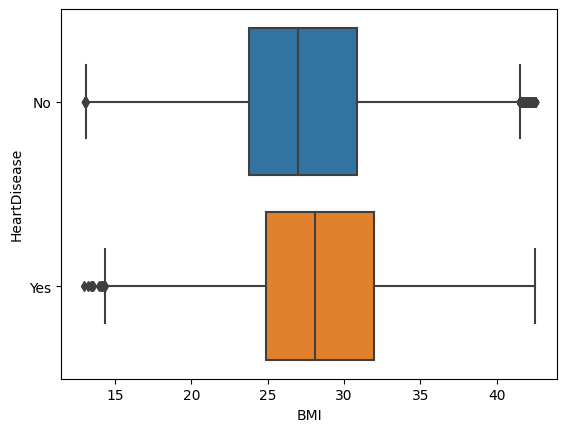

In [10]:
no_outlier = no_outlier_data(colname, check_data)
sns.boxplot(data=no_outlier, x=colname, y='HeartDisease');

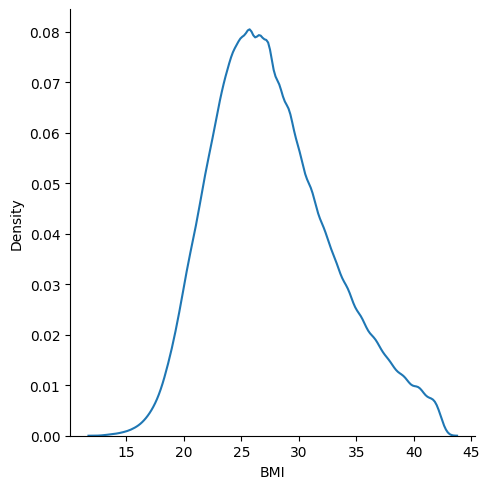

In [11]:
sns.displot(data=no_outlier, x=colname, kind='kde');

In [12]:
model = ols(f'HeartDisease_no ~ {colname}', data=no_outlier).fit()            
coff = pointbiserialr(no_outlier[colname], no_outlier['HeartDisease_no'])
    
display(sm.stats.anova_lm(model, typ=2))
print(f'Correlation coefficient: {coff[0]}')
print(f'P-value: {coff[1]}')

,sum_sq,df,F,PR(>F)
BMI,66.386834,1.0,859.169285,1.340662e-188
Residual,23906.682600,309397.0,NaN,NaN


Correlation coefficient: 0.052623430785802235
P-value: 1.3406623268051114e-188


In [13]:
check_data.shape[0] - no_outlier.shape[0]

10396

Ta có thể thấy:
+ Đã theo phân phối chuẩn.
+ Sự khác biệt đã rõ ràng hơn.
+ P-value không thay đổi quá nhiều.
+ Có tới hơn 10k dòng chứa dữ liệu outlier.

=> Các outlier có ảnh hưởng nhất định, xem xét quá trình transformation.

### Transformation

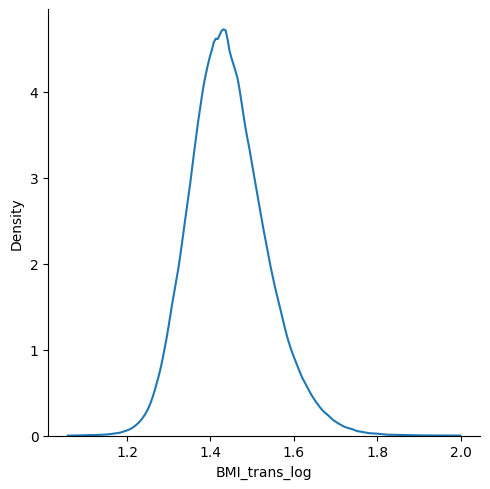

In [14]:
check_data['BMI_trans_log'] = np.log10(data['BMI'])
sns.displot(data=check_data, x=f'{colname}_trans_log', kind='kde');

In [15]:
check_data = transformation('BMI', check_data)
model = ols('HeartDisease_no ~ BMI_trans_log', data=check_data).fit()            
coff = pointbiserialr(check_data['BMI_trans_sqrt'], check_data['HeartDisease_no'])
    
display(sm.stats.anova_lm(model, typ=2))
print(f'Correlation coefficient: {coff[0]}')
print(f'P-value: {coff[1]}')

,sum_sq,df,F,PR(>F)
BMI_trans_log,72.894450,1.0,934.048185,7.701388e-205
Residual,24957.101034,319793.0,NaN,NaN


Correlation coefficient: 0.0531828937785352
P-value: 5.411711437312411e-199


Ta thấy phân phối đã gần chuẩn hơn. 

Kết luận: giữ lại biến BMI, transform lại bằng phương thức log10.

## SleepTime

In [16]:
colname='SleepTime'

### Distribution

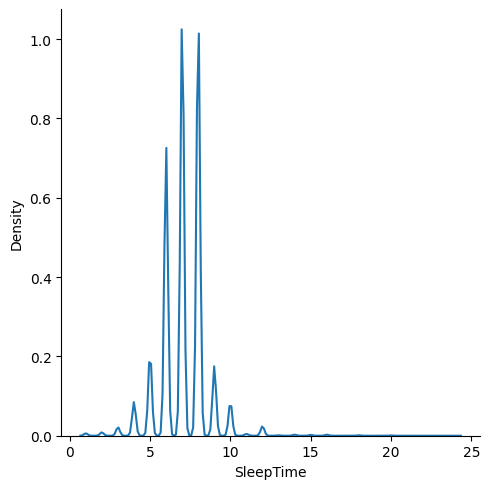

In [17]:
sns.displot(check_data, x='SleepTime', kind='kde')

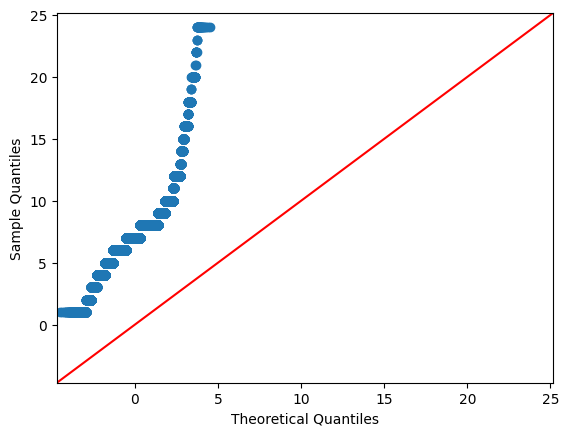

In [18]:
fig = sm.qqplot(check_data['SleepTime'], line='45')
plt.show()

Nhận xét:
+ Đây không phải là phân phối chuẩn.
+ Đuôi hơi dài.

### Difference checking between 'SleepTime' and 'HeartDisease'

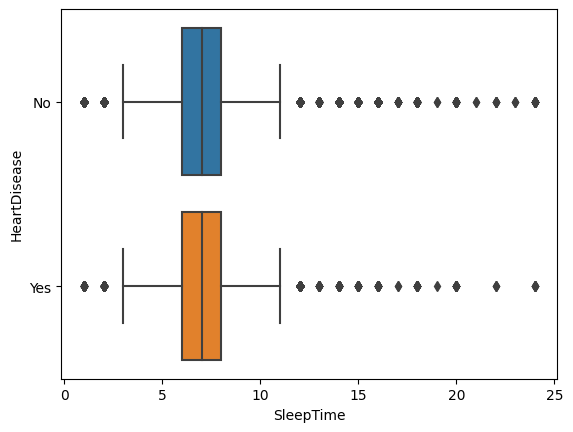

In [19]:
sns.boxplot(data=check_data, x=colname, y='HeartDisease');

Ta thấy biến SleepTime không có ảnh hưởng đến biến HeartDisease. Tính toán hệ số tương quan để kiểm chứng.

### Correlation checking

In [20]:
model = ols(f'HeartDisease_no ~ {colname}', data=check_data).fit()            
coff = pointbiserialr(check_data[colname], check_data['HeartDisease_no'])
    
display(sm.stats.anova_lm(model, typ=2))
print(f'Correlation coefficient: {coff[0]}')
print(f'P-value: {coff[1]}')

,sum_sq,df,F,PR(>F)
SleepTime,1.735406,1.0,22.173761,0.000002
Residual,25028.260079,319793.0,NaN,NaN


Correlation coefficient: 0.008326646858292937
P-value: 2.491586575837222e-06


Nhận xét:
+ P-value < 0.05 --> sự tương quan giữa 2 biến có ý nghĩa thống kê.
+ Hệ số tương quan rất nhỏ --> tương quan cực yếu.
+ Có outlier, cần kiểm tra thêm.

### No outlier

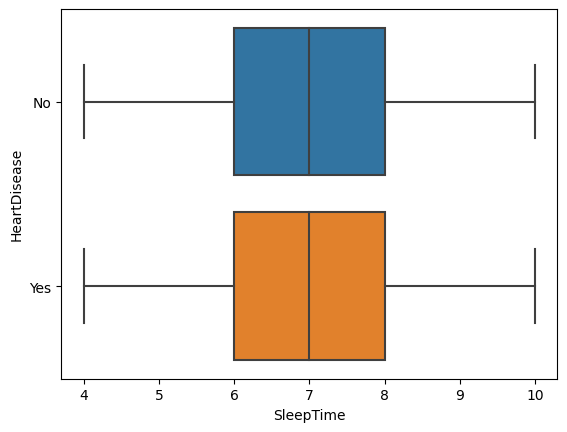

In [21]:
no_outlier = no_outlier_data(colname, check_data)
sns.boxplot(data=no_outlier, x=colname, y='HeartDisease');

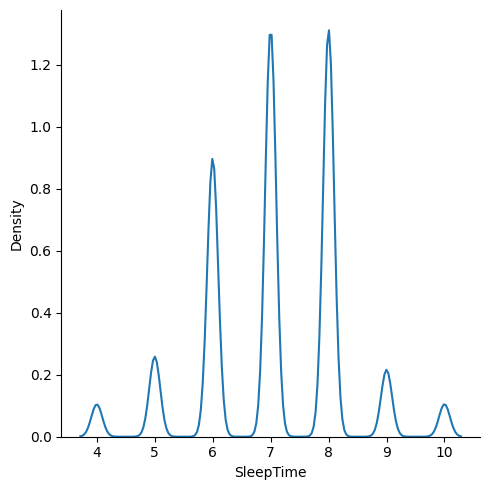

In [22]:
sns.displot(no_outlier, x='SleepTime', kind='kde')

In [23]:
model = ols(f'HeartDisease_no ~ {colname}', data=no_outlier).fit()            
coff = pointbiserialr(no_outlier[colname], no_outlier['HeartDisease_no'])
    
display(sm.stats.anova_lm(model, typ=2))
print(f'Correlation coefficient: {coff[0]}')
print(f'P-value: {coff[1]}')

,sum_sq,df,F,PR(>F)
SleepTime,0.049541,1.0,0.646041,0.421532
Residual,23989.946093,312843.0,NaN,NaN


Correlation coefficient: 0.0014370319642941563
P-value: 0.42153224110679843


Ta có thể thấy:
+ Phân phối không đổi.
+ Không thấy được sự khác biệt ở box plot.
+ P-value > 0.05 => chấp nhận giả thuyết rằng mối tương quan không có ý nghĩa thống kê.

Kết luận: biến ko phù hợp để đưa vào mô hình.

## PhysicalHealth

In [24]:
colname='PhysicalHealth'

### Distribution

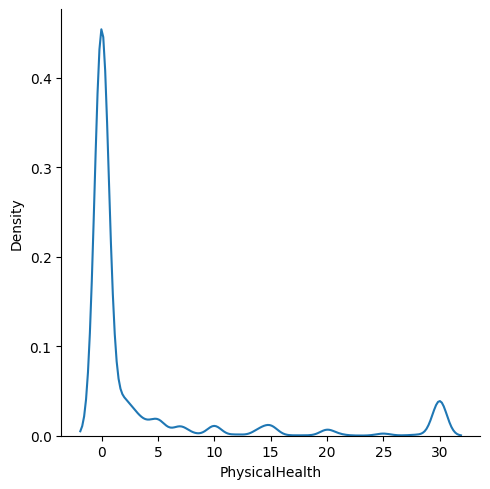

In [25]:
sns.displot(check_data, x='PhysicalHealth', kind='kde')

Nhận xét:
+ Bị lệch phải mạnh.
+ Đuôi khá dài.

### Difference checking between 'PhysicalHealth' and 'HeartDisease'

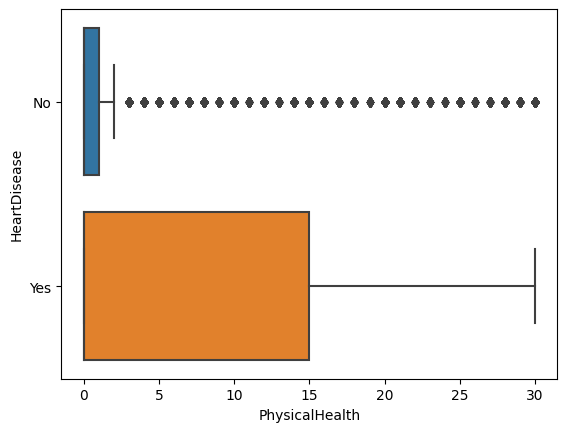

In [26]:
sns.boxplot(data=check_data, x=colname, y='HeartDisease');

Ta thấy biến PhysicalHealth có ảnh hưởng nhất định đến biến HeartDisease. Tính toán hệ số tương quan để kiểm chứng.

### Correlation checking

In [27]:
model = ols(f'HeartDisease_no ~ {colname}', data=check_data).fit()            
coff = pointbiserialr(check_data[colname], check_data['HeartDisease_no'])
    
display(sm.stats.anova_lm(model, typ=2))
print(f'Correlation coefficient: {coff[0]}')
print(f'P-value: {coff[1]}')

,sum_sq,df,F,PR(>F)
PhysicalHealth,729.515495,1.0,9600.384382,0.0
Residual,24300.479990,319793.0,NaN,NaN


Correlation coefficient: 0.1707209719663833
P-value: 0.0


Nhận xét:
+ P-value < 0.05 --> sự tương quan giữa 2 biến có ý nghĩa thống kê.
+ Hệ số tương quan nhỏ --> tương quan yếu.
+ Có outlier, cần kiểm tra thêm.

### No outlier

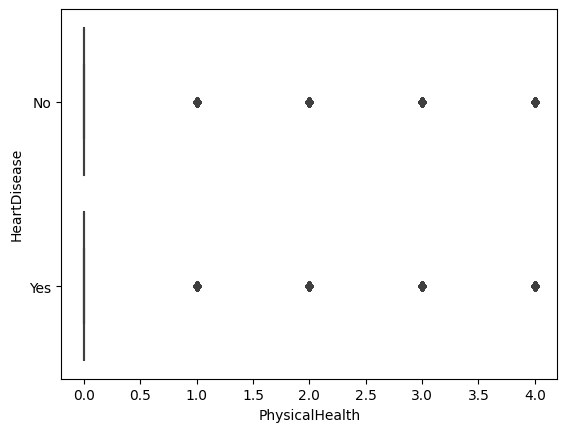

In [28]:
no_outlier = no_outlier_data(colname, check_data)
sns.boxplot(data=no_outlier, x=colname, y='HeartDisease');

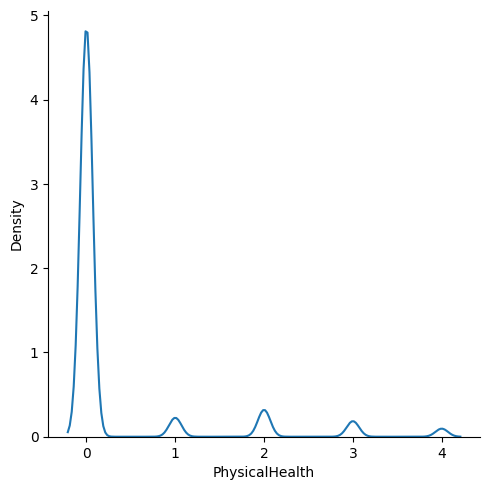

In [29]:
sns.displot(no_outlier, x='PhysicalHealth', kind='kde')

In [30]:
model = ols(f'HeartDisease_no ~ {colname}', data=no_outlier).fit()
coff = pointbiserialr(no_outlier[colname], no_outlier['HeartDisease_no'])
    
display(sm.stats.anova_lm(model, typ=2))
print(f'Correlation coefficient: {coff[0]}')
print(f'P-value: {coff[1]}')

,sum_sq,df,F,PR(>F)
PhysicalHealth,18.623011,1.0,301.803701,1.453252e-67
Residual,16354.542212,265041.0,NaN,NaN


Correlation coefficient: 0.03372551760917821
P-value: 1.4532520753201116e-67


c:\Users\trinh\anaconda3\envs\data_mining\lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


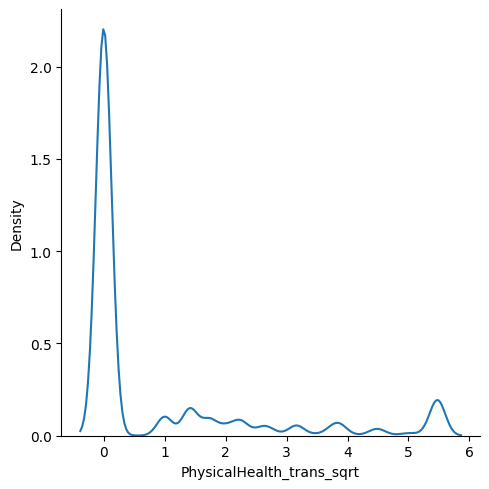

In [31]:
check_data = transformation(colname, check_data)
sns.displot(check_data[f'{colname}_trans_sqrt'], kind='kde');

In [32]:
model = ols(f'HeartDisease_no ~ {colname}_trans_sqrt', data=check_data).fit()            
coff = pointbiserialr(check_data[f'{colname}_trans_sqrt'], check_data['HeartDisease_no'])
    
display(sm.stats.anova_lm(model, typ=2))
print(f'Correlation coefficient: {coff[0]}')
print(f'P-value: {coff[1]}')

,sum_sq,df,F,PR(>F)
PhysicalHealth_trans_sqrt,710.704243,1.0,9345.594804,0.0
Residual,24319.291242,319793.0,NaN,NaN


Correlation coefficient: 0.16850549519501082
P-value: 0.0


Ta có thể thấy:
+ Phân phối không thay đổi nhiều.
+ Không có outlier, ta không thấy sự khác biệt => outlier chứa thông tin quan trọng ảnh hưởng đến biến target.
+ P-value > 0.05 => chấp nhận giả thuyết rằng mối tương quan không có ý nghĩa thống kê.

Kết luận: biến phù hợp để đưa vào mô hình, transform bằng sqrt.

## MentalHealth

In [33]:
colname='MentalHealth'

### Distribution

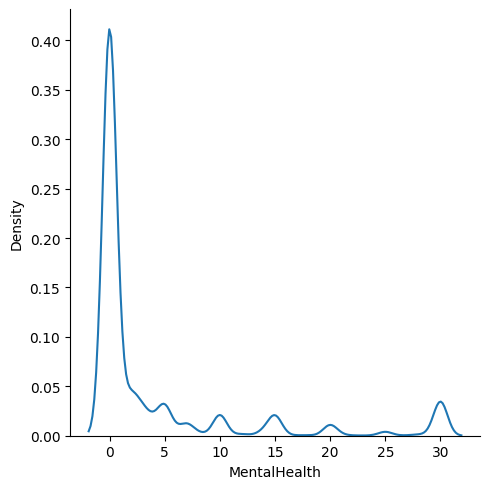

In [34]:
sns.displot(check_data, x='MentalHealth', kind='kde')

Nhận xét:
+ Bị lệch phải mạnh.
+ Đuôi khá dài.

### Difference checking between 'MentalHealth' and 'HeartDisease'

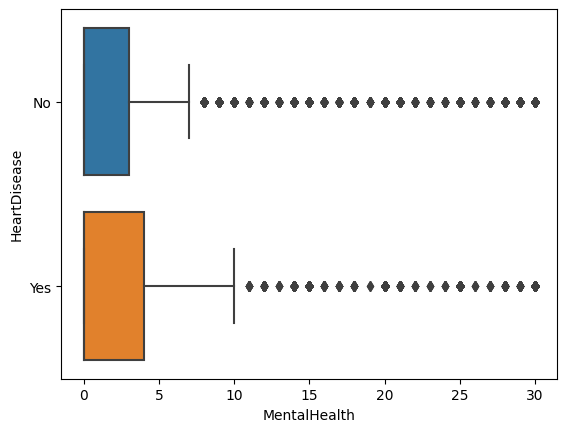

In [35]:
sns.boxplot(data=check_data, x=colname, y='HeartDisease');

Ta thấy biến MentalHealth có ảnh hưởng rất nhỏ đến biến HeartDisease. Tính toán hệ số tương quan để kiểm chứng.

### Correlation checking

In [36]:
model = ols(f'HeartDisease_no ~ {colname}', data=check_data).fit()            
coff = pointbiserialr(check_data[colname], check_data['HeartDisease_no'])
    
display(sm.stats.anova_lm(model, typ=2))
print(f'Correlation coefficient: {coff[0]}')
print(f'P-value: {coff[1]}')

,sum_sq,df,F,PR(>F)
MentalHealth,20.460243,1.0,261.621916,8.023875e-59
Residual,25009.535241,319793.0,NaN,NaN


Correlation coefficient: 0.028590714546923753
P-value: 8.023874539081988e-59


Nhận xét:
+ P-value < 0.05 --> sự tương quan giữa 2 biến có ý nghĩa thống kê.
+ Hệ số tương quan rất nhỏ --> tương quan rất yếu.
+ Có outlier, cần kiểm tra thêm.

### No outlier

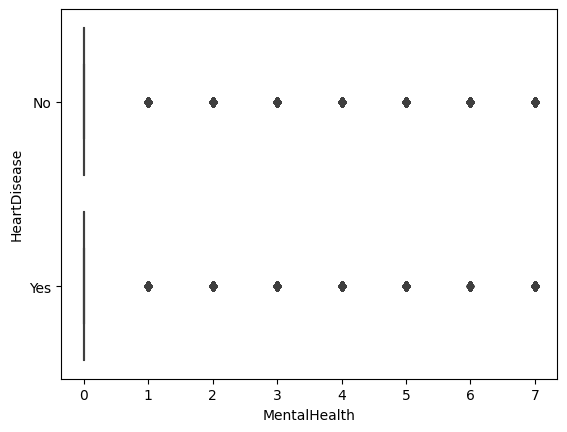

In [37]:
no_outlier = no_outlier_data(colname, check_data)
sns.boxplot(data=no_outlier, x=colname, y='HeartDisease');

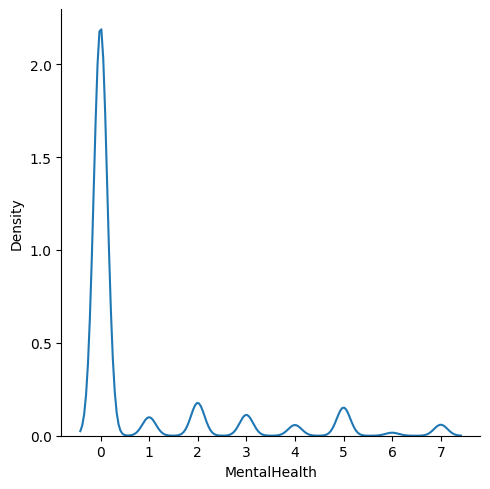

In [38]:
sns.displot(no_outlier, x='MentalHealth', kind='kde')

In [39]:
model = ols(f'HeartDisease_no ~ {colname}', data=no_outlier).fit()
coff = pointbiserialr(no_outlier[colname], no_outlier['HeartDisease_no'])
    
display(sm.stats.anova_lm(model, typ=2))
print(f'Correlation coefficient: {coff[0]}')
print(f'P-value: {coff[1]}')

,sum_sq,df,F,PR(>F)
MentalHealth,25.194189,1.0,332.789846,2.631635e-74
Residual,20305.637087,268217.0,NaN,NaN


Correlation coefficient: -0.03520242848678856
P-value: 2.6316346924240307e-74


Nhận xét: 
+ Khi không có outlier, không có sự khác biệt ở biến HeartDisease => outlier chứa thông tin có lợi, tuy ảnh hưởng nhỏ.
+ P-value và hệ số tương quan không thay đổi nhiều.

### Transformation

c:\Users\trinh\anaconda3\envs\data_mining\lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


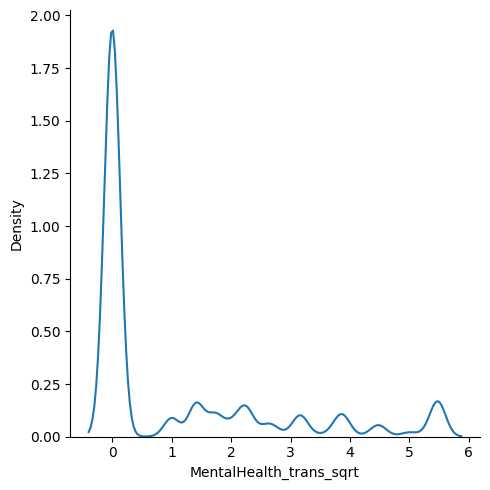

In [40]:
check_data = transformation(colname, check_data)

sns.displot(check_data[f'{colname}_trans_sqrt'], kind='kde');

In [41]:
model = ols(f'HeartDisease_no ~ {colname}_trans_sqrt', data=check_data).fit()            
coff = pointbiserialr(check_data[f'{colname}_trans_sqrt'], check_data['HeartDisease_no'])
    
display(sm.stats.anova_lm(model, typ=2))
print(f'Correlation coefficient: {coff[0]}')
print(f'P-value: {coff[1]}')

,sum_sq,df,F,PR(>F)
MentalHealth_trans_sqrt,4.336198,1.0,55.410556,9.805325e-14
Residual,25025.659287,319793.0,NaN,NaN


Correlation coefficient: 0.013162068741034594
P-value: 9.805325214706043e-14


Ta có thể thấy:
+ Phân phối không thay đổi nhiều.
+ P-value > 0.05 => chấp nhận giả thuyết rằng mối tương quan có ý nghĩa thống kê.
+ Hệ số tương quan nhỏ.

Kết luận: biến không phù hợp để đưa vào mô hình.

## First conclude

In [42]:
data['BMI'] = np.log10(data['BMI'])
data['PhysicalHealth'] = np.sqrt(data['PhysicalHealth'])
data.drop(['MentalHealth', 'SleepTime'], axis=1, inplace=True)

# Dichotomous features

In [43]:
check_data = data.select_dtypes('object').drop(['AgeCategory', 'Diabetic', 'Race', 'GenHealth'], axis=1)
check_data['HeartDisease_no'] = check_data['HeartDisease'].replace({'No':0, 'Yes':1}).values
check_data = check_data.drop(['HeartDisease'], axis=1).replace({'No':0, 'Yes':1, 'Female':0, 'Male':1})

check_data.head()

,Smoking,AlcoholDrinking,Stroke,DiffWalking,Sex,PhysicalActivity,Asthma,KidneyDisease,SkinCancer,HeartDisease_no
0,1,0,0,0,0,1,1,0,1,0
1,0,0,1,0,0,1,0,0,0,0
2,1,0,0,0,1,1,1,0,0,0
3,0,0,0,0,0,0,0,0,1,0
4,0,0,0,1,0,1,0,0,0,0


## Statistical test

### Chi-Square test
Check if there is any significant correlation between 2 categorical data.

In [44]:
coef = [
    chi2_contingency(pd.crosstab(check_data[col], check_data['HeartDisease_no']))[0]
    for col in check_data.columns[:-1]
]
pv = [
    chi2_contingency(pd.crosstab(check_data[col], check_data['HeartDisease_no']))[1]
    for col in check_data.columns[:-1]
]
chi2 = pd.DataFrame({'Columns':check_data.columns[:-1], 'Coeffiencient':coef, 'P-value':pv}).sort_values(by='Coeffiencient', ascending=False)
chi2

,Columns,Coeffiencient,P-value
3,DiffWalking,12951.153005,0.000000e+00
2,Stroke,12386.488880,0.000000e+00
7,KidneyDisease,6739.226168,0.000000e+00
0,Smoking,3713.033147,0.000000e+00
5,PhysicalActivity,3199.008158,0.000000e+00
8,SkinCancer,2783.640540,0.000000e+00
4,Sex,1568.306917,0.000000e+00
6,Asthma,548.850841,2.238614e-121
1,AlcoholDrinking,328.649169,1.892352e-73


### Cramers'v
Measure of the strength of association between 2 nomial data.

In [45]:
coef = [
    cramers_v(check_data[col], check_data['HeartDisease_no'])[0]
    for col in check_data.columns[:-1]
]
cramers_v2 = pd.DataFrame({'Columns':check_data.columns[:-1], 'Coeffiencient':coef}).sort_values(by='Coeffiencient', ascending=False)
cramers_v2

,Columns,Coeffiencient
3,DiffWalking,0.201242
2,Stroke,0.196806
7,KidneyDisease,0.145167
0,Smoking,0.107753
5,PhysicalActivity,0.100017
8,SkinCancer,0.093298
4,Sex,0.070029
6,Asthma,0.041428
1,AlcoholDrinking,0.032058


### Nhận xét:
+ Kết quả tương quan của 2 biến 'AlcoholDrinking' và 'Asthma' là rất thấp so với còn lại --> loại bỏ.
+ Dữ liệu thuộc lĩnh vực y tế nên ta sẽ lấy 0.1 là giới hạn.

==> Các biến bị loại: 'AlcoholDrinking', 'Asthma', 'Sex', 'SkinCancer'.

In [46]:
data.drop(['AlcoholDrinking', 'Asthma', 'Sex', 'SkinCancer'], axis=1, inplace=True)

# Nominal data

In [47]:
check_data = data[['AgeCategory', 'Race', 'Diabetic', 'GenHealth']]
check_data.loc[:, 'HeartDisease_no'] = data['HeartDisease'].replace({'No':0, 'Yes':1}).values
check_data

C:\Users\trinh\AppData\Local\Temp\ipykernel_17684\3326811660.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  check_data.loc[:, 'HeartDisease_no'] = data['HeartDisease'].replace({'No':0, 'Yes':1}).values


,AgeCategory,Race,Diabetic,GenHealth,HeartDisease_no
0,55-59,White,Yes,Very good,0
1,80 or older,White,No,Very good,0
2,65-69,White,Yes,Fair,0
3,75-79,White,No,Good,0
4,40-44,White,No,Very good,0
...,...,...,...,...,...
319790,60-64,Hispanic,Yes,Fair,1
319791,35-39,Hispanic,No,Very good,0
319792,45-49,Hispanic,No,Good,0
319793,25-29,Hispanic,No,Good,0


In [48]:
coef = [
    chi2_contingency(pd.crosstab(check_data[col], check_data['HeartDisease_no']))[0]
    for col in check_data.columns[:-1]
]
pv = [
    chi2_contingency(pd.crosstab(check_data[col], check_data['HeartDisease_no']))[1]
    for col in check_data.columns[:-1]
]
chi1 = pd.DataFrame({'Columns':check_data.columns[:-1], 'Coeffiencient':coef, 'P-value':pv}).sort_values(by='Coeffiencient', ascending=False)
chi1

,Columns,Coeffiencient,P-value
3,GenHealth,21542.177361,0.000000e+00
0,AgeCategory,19299.920391,0.000000e+00
2,Diabetic,10959.861277,0.000000e+00
1,Race,844.314886,2.988613e-180


In [49]:
coef = [
    cramers_v(check_data[col], check_data['HeartDisease_no'])[0]
    for col in check_data.columns[:-1]
]
cramers_v3 = pd.DataFrame({'Columns':check_data.columns[:-1], 'Coeffiencient':coef}).sort_values(by='Coeffiencient', ascending=False)
cramers_v3

,Columns,Coeffiencient
3,GenHealth,0.259543
0,AgeCategory,0.245664
2,Diabetic,0.185126
1,Race,0.051383


Như đã nói ở trên, ta lấy 0.1 là giới hạn xem xét nên biến 'Race' sẽ bị loại bỏ.

In [50]:
data.drop(['Race'], axis=1, inplace=True)

# Final data

In [51]:
data.head()

,HeartDisease,BMI,Smoking,Stroke,PhysicalHealth,DiffWalking,AgeCategory,Diabetic,PhysicalActivity,GenHealth,KidneyDisease
0,No,1.220108,Yes,No,1.732051,No,55-59,Yes,Yes,Very good,No
1,No,1.308351,No,Yes,0.000000,No,80 or older,No,Yes,Very good,No
2,No,1.424555,Yes,No,4.472136,No,65-69,Yes,Yes,Fair,No
3,No,1.383995,No,No,0.000000,No,75-79,No,No,Good,No
4,No,1.374932,No,No,5.291503,Yes,40-44,No,Yes,Very good,No


In [52]:
final_data = data.copy()

# Shorten data value
final_data['Diabetic'] = final_data['Diabetic'].apply(diabetic)

# Encode dichotomous feature
final_data = final_data.replace({'No':0, 'Yes':1})

# Label encoding for 'GenHealth' and 'AgeCategory'
final_data['GenHealth'] = LabelEncoder().fit_transform(final_data['GenHealth'])
final_data['AgeCategory'] = LabelEncoder().fit_transform(final_data['AgeCategory'])

# Get dummy for 'Diabetic'
final_data = pd.get_dummies(final_data, columns=['Diabetic'])

# Encode boolean features and concatenate data
final_data = fix(final_data)

In [53]:
final_data.head()

,HeartDisease,Smoking,Stroke,DiffWalking,AgeCategory,PhysicalActivity,GenHealth,KidneyDisease,BMI,PhysicalHealth,Diabetic_borderline,Diabetic_pregnancy
0,0,1,0,0,7,1,4,0,1.220108,1.732051,0,0
1,0,0,1,0,12,1,4,0,1.308351,0.000000,0,0
2,0,1,0,0,9,1,1,0,1.424555,4.472136,0,0
3,0,0,0,0,11,0,2,0,1.383995,0.000000,0,0
4,0,0,0,1,4,1,4,0,1.374932,5.291503,0,0


In [54]:
final_data.to_csv('data/final_data.csv', index=False)